# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

####  Answer : VAE Concept & Reparameterization Trick


A Variational Autoencoder is a generative model that learns a *probabilistic* latent space. Unlike a standard autoencoder, which maps each input to a single fixed point(which lead to the creation of voids), the VAE encoder maps each input to a **distribution** $\mathcal{N}(\mu, \sigma^2)$ and samples a latent vector from it(which ensures that there is no void).

**Role of $\mu$ (mean):** The centre of the latent distribution for a given input, the most likely location of $z$.

**Role of $\log(\sigma^2)$ (log-variance):** Controls the spread/uncertainty of the distribution. We use log-variance instead of variance directly for numerical stability.(because log can output negative values).

**Reparameterization Trick:**
Sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is not differentiable, so gradients cannot flow back through it. The trick re-writes the sample as:
$z = \mu + \sigma \odot \varepsilon$, where $\varepsilon$ is from a normal distribution with mean 0 and variance 1.
Now the randomness is isolated in $\varepsilon$ (no learnable parameters). Gradients flow cleanly through $\mu$ and $\sigma = \exp(0.5 \cdot \log\sigma^2)$, making end-to-end backpropagation possible.


In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # ==== Encoder ====
        self.fc1 = nn.Linear(input_dim, hidden_dim)   # input → hidden

        # Latent distribution parameters
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)  # hidden to μ
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # hidden to log σ²

        # ==== Decoder ====
        self.fc3 = nn.Linear(latent_dim, hidden_dim)  # latent to hidden
        self.fc4 = nn.Linear(hidden_dim, input_dim)   # hidden to reconstructed image

    def encode(self, x):
        x = x.view(x.size(0), -1)        # flatten: (B,1,28,28) to (B,784)
        h = F.relu(self.fc1(x))           # shared hidden representation
        mu = self.fc_mu(h)             # mean vector
        logvar = self.fc_logvar(h)         # log-variance vector
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)  # sigma = exp(0.5 * log(square(sigma)))
            eps = torch.randn_like(std)    # epsilon ~ N(0, I)
            return mu + std * eps          # z = mu + sigma * epsilon
        else:
            return mu                      # at inference, use the mean

    def decode(self, z):
        h  = F.relu(self.fc3(z))
        recon = torch.sigmoid(self.fc4(h))  # pixel values in [0, 1]
        return recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


# Instantiate the model
model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

Total parameters: 652,824


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

####  Answer : VAE Loss Function

The total VAE loss combines two terms: **Reconstruction(BCE)** and **Regularisation(KL Divergence)**

**1. Reconstruction Loss (BCE)**
Measures how accurately the decoder rebuilds the original image pixel-by-pixel. Binary Cross-Entropy is used because MNIST pixels are in $[0,1]$ and each pixel can be treated as an independent Bernoulli variable.

   **BCE** = -[y.log(p) + (1-y).log(1-p)]   (We sum it for all the pixels of all the images in the batch)
   
**2. KL Divergence**
Measures how far the encoder's distribution $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ deviates from the standard normal prior $p(z) = \mathcal{N}(0, I)$.
- It regularises the latent space, preventing it from collapsing to a standard AE.
- It ensures latent codes are organised and overlapping so we can sample any $z \sim \mathcal{N}(0, I)$ and get a meaningful image.

Closed-form for diagonal Gaussians:

$D_{KL} = -\frac{1}{2}\left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$ (We sum it over the dimensions(20) of the latent space )


In [4]:
def vae_loss(recon_x, x, mu, logvar):
    # Flatten the target image to (B, 784) to match recon_x
    x_flat = x.view(x.size(0), -1)

    # 1) Reconstruction loss : summed over pixels, summed over batch
    BCE = F.binary_cross_entropy(recon_x, x_flat, reduction='sum')

    # 2) KL Divergence: -0.5 * sum(1 + log σ² - μ² - σ²)
    #    Summed over latent dims and over batch
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD


print("VAE loss function defined ")


VAE loss function defined 


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [5]:
# ===== Hyperparameters =====
batch_size    = 128
epochs        = 15
learning_rate = 1e-3

# ===== Data Loading ======
# ToTensor() converts PIL image (0-255) to float Tensor (0.0-1.0)
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ==== Optimizer ======
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ===== Training Loop =====
train_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0

    for data, _ in train_loader:
        data = data.to(device)              # move batch to device

        optimizer.zero_grad()               # clear previous gradients

        recon_batch, mu, logvar = model(data)        # forward pass
        loss = vae_loss(recon_batch, data, mu, logvar)  # compute loss

        loss.backward()                     # backpropagate
        optimizer.step()                    # update weights

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch:>2}/{epochs}]  Loss: {avg_loss:.4f}")

print("\nTraining complete! ")


100%|██████████| 9.91M/9.91M [00:00<00:00, 65.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.4MB/s]


Epoch [ 1/15]  Loss: 165.0649
Epoch [ 2/15]  Loss: 120.9362
Epoch [ 3/15]  Loss: 114.0652
Epoch [ 4/15]  Loss: 111.1394
Epoch [ 5/15]  Loss: 109.3757
Epoch [ 6/15]  Loss: 108.2412
Epoch [ 7/15]  Loss: 107.4106
Epoch [ 8/15]  Loss: 106.7750
Epoch [ 9/15]  Loss: 106.2921
Epoch [10/15]  Loss: 105.8447
Epoch [11/15]  Loss: 105.5259
Epoch [12/15]  Loss: 105.1719
Epoch [13/15]  Loss: 104.9240
Epoch [14/15]  Loss: 104.7067
Epoch [15/15]  Loss: 104.4926

Training complete! 


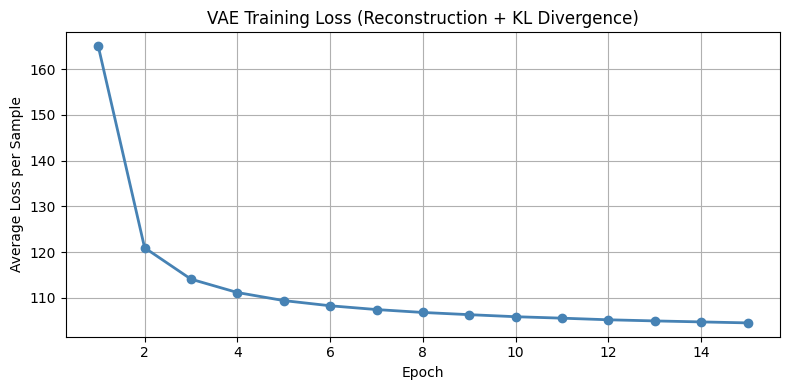

In [6]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.title("VAE Training Loss (Reconstruction + KL Divergence)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Sample")
plt.grid(True)
plt.tight_layout()
plt.show()


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

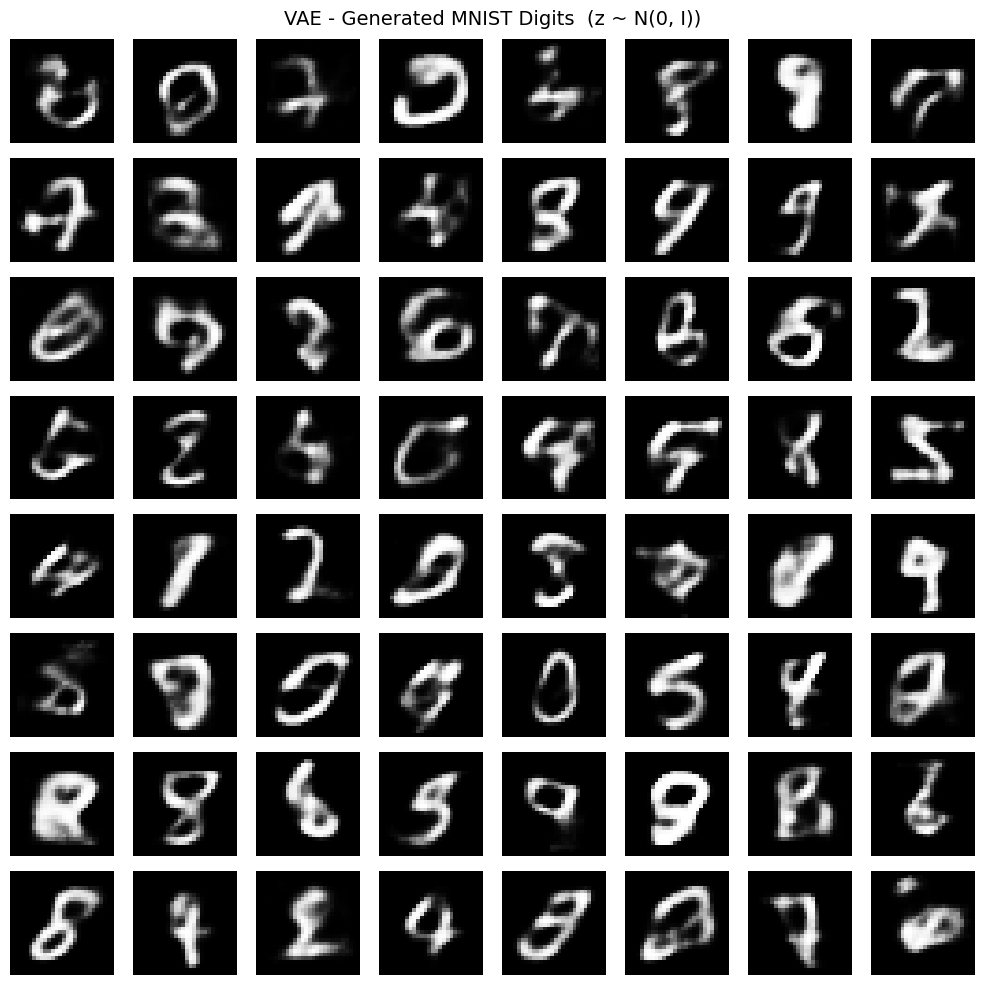

In [7]:
model.eval()   # switch to evaluation mode
n_samples = 64

with torch.no_grad():
    # Sample z from the standard normal prior p(z) = N(0, I)
    z = torch.randn(n_samples, 20).to(device)  # latent_dim = 20
    generated = model.decode(z).view(n_samples, 1, 28, 28).cpu()

# Visualise in an 8×8 grid
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle("VAE - Generated MNIST Digits  (z ~ N(0, I))", fontsize=14)
plt.tight_layout()
plt.show()


#### Interpretation : Generated Sample Quality


**Quality of generated digits:**

After 15 epochs, the generated samples are mixed in quality. Some are clearly recognizable as digits (e.g., a few 8s), but many others are blurry or ambiguous .It's hard to tell which digit was intended. This suggests the model has learned the general structure of digits (loops, strokes, curves) but hasn't fully converged on sharp, distinct digit classes after this number of epochs.

**Why the samples look blurry/unclear:**

VAEs tend to do this. The loss function doesn't make the model to produce one perfect output ,it makes the model balance across several possible outputs for the same point in latent space. On top of that, the KL term pushes the digit groups closer together so they overlap more. Because of this overlap, points that fall between two different digits get blended, and the decoder produces a blurry, in-between result instead of a clean one.

**What this suggests about the latent space:**

The latent space is continuous (no hard gaps), but not yet cleanly separated into distinct digit clusters. Random samples from $N(0, I)$ sometimes land in blended regions between two digit types, producing ambiguous shapes. This could likely be improved with more training epochs, a larger latent dimension, or by using convolution layers.